In [1]:
# Cell 1: Import necessary libraries for the ML Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules for preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Sklearn metrics for evaluation
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

# Joblib for model saving (Deployment)
import joblib

In [2]:
# Cell 2: File Upload
from google.colab import files

print("Please upload your CSV file...")
uploaded = files.upload()

Please upload your CSV file...


Saving Telco_customer_churn_dataset.xlsx to Telco_customer_churn_dataset.xlsx


In [3]:
# Cell 3: Load the uploaded dataset into a DataFrame
import pandas as pd
import io

file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f"\n✅ '{file_name}' successfully loaded into DataFrame!")

df.head()


✅ 'Telco_customer_churn_dataset.xlsx' successfully loaded into DataFrame!


,CustomerID,Count,Lat Long,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,3668-QPYBK,1,"33.964131, -118.272783",Male,No,No,No,2,Yes,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
1,9237-HQITU,1,"34.059281, -118.30742",Female,No,No,Yes,2,Yes,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
2,9305-CDSKC,1,"34.048013, -118.293953",Female,No,No,Yes,8,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
3,7892-POOKP,1,"34.062125, -118.315709",Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
4,0280-XJGEX,1,"34.039224, -118.266293",Male,No,No,Yes,49,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Lat Long           7043 non-null   object 
 3   Gender             7043 non-null   object 
 4   Senior Citizen     7043 non-null   object 
 5   Partner            7043 non-null   object 
 6   Dependents         7043 non-null   object 
 7   Tenure Months      7043 non-null   int64  
 8   Phone Service      7043 non-null   object 
 9   Multiple Lines     7043 non-null   object 
 10  Internet Service   7043 non-null   object 
 11  Online Security    7043 non-null   object 
 12  Online Backup      7043 non-null   object 
 13  Device Protection  7043 non-null   object 
 14  Tech Support       7043 non-null   object 
 15  Streaming TV       7043 non-null   object 
 16  Streaming Movies   7043 

In [5]:
# Cell 4: Data Pre-processing
print("Starting Data Cleaning...")

# 1. Drop useless columns (wadak nathi columns ain kirima)
columns_to_drop = ['CustomerID', 'Count', 'Lat Long', 'Country', 'State', 'City', 'Zip Code']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# 2. Fix 'Total Charges' column (Numbers walata harawamu, his than NaN wenawa)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 3. Fill missing values in 'Total Charges' with the median value (his than median eken fill karamu)
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

# 4. Drop any duplicate rows (samana rows ain karamu)
df = df.drop_duplicates()

print("✅ Data Cleaning Complete!")
print(f"Dataset shape after cleaning: {df.shape}")

# Check if there are any missing values left
missing_values = df.isnull().sum().sum()
print(f"Total missing values remaining: {missing_values}")

Starting Data Cleaning...
✅ Data Cleaning Complete!
Dataset shape after cleaning: (7021, 20)
Total missing values remaining: 0


In [6]:
# Cell 5: Feature Engineering & Data Splitting
print("Starting Feature Engineering...")

# 1. Encode Target Variable (Churn Label: Yes->1, No->0)
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# 2. Encode other categorical features using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Define Features (X) and Target (y)
X = df_encoded.drop('Churn Label', axis=1)
y = df_encoded['Churn Label']

# 4. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the features (Normalize data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature Engineering & Splitting Complete!")
print(f"Training data shape (Rows, Columns): {X_train_scaled.shape}")
print(f"Testing data shape (Rows, Columns): {X_test_scaled.shape}")

Starting Feature Engineering...
✅ Feature Engineering & Splitting Complete!
Training data shape (Rows, Columns): (5616, 30)
Testing data shape (Rows, Columns): (1405, 30)


In [7]:
# Cell 6: Model Training & Selection
print("Starting Model Training...\n")

# Define the models based on the proposal
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

best_model = None
best_accuracy = 0
best_model_name = ""

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test_scaled)

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

    # Check if this model is the best one so far
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print(f"\n🏆 Best Model Selected: {best_model_name} with an Accuracy of {best_accuracy:.4f}")

Starting Model Training...

Logistic Regression Accuracy: 0.8100
Decision Tree Accuracy: 0.7331
Random Forest Accuracy: 0.7986

🏆 Best Model Selected: Logistic Regression with an Accuracy of 0.8100


--- Evaluating Logistic Regression ---

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1008
           1       0.71      0.56      0.63       397

    accuracy                           0.81      1405
   macro avg       0.77      0.73      0.75      1405
weighted avg       0.80      0.81      0.80      1405

Precision: 0.7057
F1-Score: 0.6255

Confusion Matrix Plot:


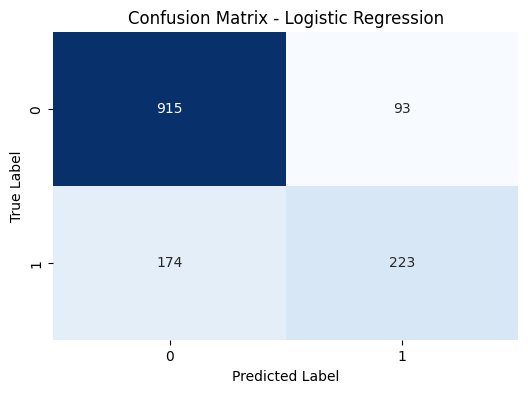

In [8]:
# Cell 7: Model Evaluation
print(f"--- Evaluating {best_model_name} ---")

# Best model eken test data walata predictions ganna
y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Precision saha F1-Score eka wena wenama ganna
precision = precision_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix eka lassanata plot karanna
print("\nConfusion Matrix Plot:")
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [9]:
# Cell 8: Save Model and Preprocessing Objects
import joblib

print("Saving models for deployment...")

# 1. Save the trained best model (Logistic Regression)
joblib.dump(best_model, 'churn_prediction_model.pkl')

# 2. Save the scaler (Backend eken ena aluth data scale karanna meka oni wenawa)
joblib.dump(scaler, 'scaler.pkl')

# 3. Save the feature columns (Backend eke data columns wala piliwela hariyata thiyaganna meka oni)
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("✅ Model, Scaler, and Columns saved successfully!")
print("Files created: churn_prediction_model.pkl, scaler.pkl, model_columns.pkl")


Saving models for deployment...
✅ Model, Scaler, and Columns saved successfully!
Files created: churn_prediction_model.pkl, scaler.pkl, model_columns.pkl
